# MSc in AI Capstone Project 3: Machine Learning Foundations
## Predicting High-Income Individuals for phiAI Donor Outreach


## Overview

This notebook builds a supervised classification model to predict whether an individual's annual income exceeds $50,000, using 1994 U.S. Census data, in support of phiAI's donor-outreach strategy (see Problem Definition below).

The dataset originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income), donated by Ron Kohavi and Barry Becker and described in Kohavi (1996), *"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"* ([online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf)). The version used here has the `fnlwgt` feature and records with missing or ill-formatted entries removed.


## Defining the Problem

**phiAI** is an EdTech-focused nonprofit that funds STEM scholarships for underserved students. To sustain and grow its scholarship programs, phiAI needs to identify individuals who are likely high-income earners, since this group is statistically more likely to make significant charitable donations. Rather than reaching out to its full contact list at equal cost and effort, phiAI wants to prioritize outreach toward individuals whose profile suggests annual income above \$50,000.

**Task type**: This is a **supervised learning, binary classification** problem. The target label, `income`, takes two values (`>50K` and `<=50K`), and the model's job is to predict which class a given individual belongs to based on their demographic and employment attributes.

**Why classification rather than regression**: The dataset provides income only as a thresholded category rather than a continuous dollar value, so the learning task is naturally framed as predicting class membership rather than an exact income figure.

**Dataset**: This project uses the [UCI Adult / Census Income dataset](https://archive.ics.uci.edu/dataset/2/adult), originally extracted from 1994 U.S. Census Bureau data. It contains 13 demographic and employment features (age, education, occupation, hours worked per week, marital status, etc.) for each individual, with `income` as the target variable.

**Success framing for phiAI**: Because outreach has a real cost (staff time, mailing, follow-up), phiAI cares more about *precision* than pure recall -- a model that frequently flags low-income individuals as high-income wastes outreach effort, while missing some genuine high earners is a more tolerable cost. This informs the choice of evaluation metric later in the notebook (F-beta with beta = 0.5, weighting precision over recall).


## Exploring the Data

The target label is `income` (whether an individual earns more than $50,000 annually). All other columns are candidate features.


### Featureset Exploration

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education_level**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [1]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from time import time
from IPython.display import display

# Import supplementary visualization code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the Census dataset
data = pd.read_csv("census.csv")

# Success - Display the first record
display(data.head(n=5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


### Data Exploration

Total record count, class counts, and class balance for the target label.


In [2]:
# Quick sanity check on class labels before formal counting below
data['income'].value_counts()

income
<=50K    34014
>50K     11208
Name: count, dtype: int64

In [3]:
# Total number of records
n_records = len(data)

# Number of records where individual's income is more than $50,000
n_greater_50k = data[data['income'] == ">50K"].shape[0]

# Number of records where individual's income is at most $50,000
n_at_most_50k = data[data['income'] == "<=50K"].shape[0]

# Percentage of individuals whose income is more than $50,000
greater_percent = round(n_greater_50k / n_records * 100, 2)

# Print the results
print("Total number of records: {}".format(n_records))
print("Individuals making more than $50,000: {}".format(n_greater_50k))
print("Individuals making at most $50,000: {}".format(n_at_most_50k))
print("Percentage of individuals making more than $50,000: {}%".format(greater_percent))

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 24.78%


In [4]:
# Inspect column names and data types
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


### Data Quality Check

Before proceeding to preprocessing, it's worth explicitly verifying data quality rather than assuming it. The Adult/Census Income dataset is known to encode missing values in some categorical columns (`workclass`, `occupation`, `native-country`) as the string `"?"` rather than as a true `NaN`, so a standard `isnull()` check alone would miss them. Duplicate rows and out-of-range numeric values (e.g. implausible `age` or `hours-per-week` entries) are also checked, since these would not be caught by either of the checks above.


In [5]:
# Check for standard missing values
n_nan = data.isnull().sum()
n_nan = n_nan[n_nan > 0]
if len(n_nan) > 0:
    print("Missing values per column (NaN):")
    print(n_nan)
else:
    print("No NaN values found in any column.")

# Check for '?' placeholders, which this dataset commonly uses instead of NaN
print()
question_mark_found = False
for col in data.select_dtypes(include='object').columns:
    n_missing = (data[col] == '?').sum()
    if n_missing > 0:
        if not question_mark_found:
            print("Columns containing '?' placeholder values:")
            question_mark_found = True
        print(f"  {col}: {n_missing} rows ({n_missing / len(data) * 100:.2f}%)")
if not question_mark_found:
    print("No '?' placeholder values found in any column.")

# Check for duplicate rows
print()
n_duplicates = data.duplicated().sum()
if n_duplicates > 0:
    print(f"Found {n_duplicates} duplicate rows ({n_duplicates / len(data) * 100:.2f}% of data).")
else:
    print("No duplicate rows found.")

# Sanity check on numeric ranges
print()
range_checks = {
    'age': (data['age'].between(0, 100)),
    'hours-per-week': (data['hours-per-week'].between(1, 168)),
}
any_flagged = False
for col, in_range in range_checks.items():
    n_out = (~in_range).sum()
    if n_out > 0:
        any_flagged = True
        print(f"  {col}: {n_out} rows outside plausible range")
if not any_flagged:
    print("All checked numeric fields (age, hours-per-week) fall within plausible ranges.")


No NaN values found in any column.

No '?' placeholder values found in any column.

Found 5982 duplicate rows (13.23% of data).

All checked numeric fields (age, hours-per-week) fall within plausible ranges.


**Result:** No `NaN` values or `"?"` placeholders are present, and the checked numeric fields fall within plausible ranges. Duplicate rows are present (roughly 13% of the data) -- these are examined and addressed below rather than dropped automatically, since blindly deduplicating this dataset would be the wrong call (see the reasoning in the next cell).


In [6]:
# Inspect a sample of duplicated rows to understand what's driving them
dup_rows = data[data.duplicated(keep=False)].sort_values(by=list(data.columns))
print(f"Total rows involved in duplication: {len(dup_rows)}")
display(dup_rows.head(10))

# How many distinct duplicate groups are there, and how large is the biggest one?
group_sizes = data.groupby(list(data.columns)).size()
group_sizes = group_sizes[group_sizes > 1]
print(f"\nNumber of distinct value-combinations that repeat: {len(group_sizes)}")
print(f"Largest group size (same combination repeated this many times): {group_sizes.max()}")


Total rows involved in duplication: 9291


,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32051,17,Private,10th,6.0,Never-married,Handlers-cleaners,Own-child,White,Male,0.0,0.0,15.0,United-States,<=50K
42555,17,Private,10th,6.0,Never-married,Handlers-cleaners,Own-child,White,Male,0.0,0.0,15.0,United-States,<=50K
16398,17,Private,10th,6.0,Never-married,Handlers-cleaners,Own-child,White,Male,0.0,0.0,20.0,United-States,<=50K
22259,17,Private,10th,6.0,Never-married,Handlers-cleaners,Own-child,White,Male,0.0,0.0,20.0,United-States,<=50K
22990,17,Private,10th,6.0,Never-married,Handlers-cleaners,Own-child,White,Male,0.0,0.0,20.0,United-States,<=50K
10542,17,Private,10th,6.0,Never-married,Other-service,Other-relative,White,Male,0.0,0.0,15.0,United-States,<=50K
43291,17,Private,10th,6.0,Never-married,Other-service,Other-relative,White,Male,0.0,0.0,15.0,United-States,<=50K
22794,17,Private,10th,6.0,Never-married,Other-service,Own-child,Black,Male,0.0,0.0,15.0,United-States,<=50K
39672,17,Private,10th,6.0,Never-married,Other-service,Own-child,Black,Male,0.0,0.0,15.0,United-States,<=50K
8178,17,Private,10th,6.0,Never-married,Other-service,Own-child,White,Female,0.0,0.0,10.0,United-States,<=50K



Number of distinct value-combinations that repeat: 3309
Largest group size (same combination repeated this many times): 21


**Decision: duplicates are kept, not dropped.**

The original UCI Adult dataset includes a `fnlwgt` column -- a Census sampling weight estimating how many people in the U.S. population each row represents. This project's dataset has that column removed, along with a handful of other identifying fields, leaving only 13 coarse categorical/continuous features (age, workclass, education, marital-status, occupation, etc.). With `capital-gain` and `capital-loss` equal to 0 for most individuals (see the skew discussion above) and the remaining features drawn from small category sets, it is statistically expected that unrelated individuals share an identical combination of values across all 13 fields, purely by chance.

In other words, these are very unlikely to be data-entry duplicates (the same person recorded twice) -- they are distinct individuals who happen to look identical on the features retained for this project. Dropping them would not correct an error; it would discard real, valid data points, and would do so disproportionately for the most common demographic profiles, subtly distorting the class balance and feature distributions established earlier. For this reason, duplicate rows are retained through preprocessing and modeling.


## Data Preparation

No missing entries were found in the strict `NaN` sense (see Data Quality Check above). `capital-gain` and `capital-loss` are highly skewed, and categorical features require encoding before modeling.


### Transforming Skewed Continuous Features

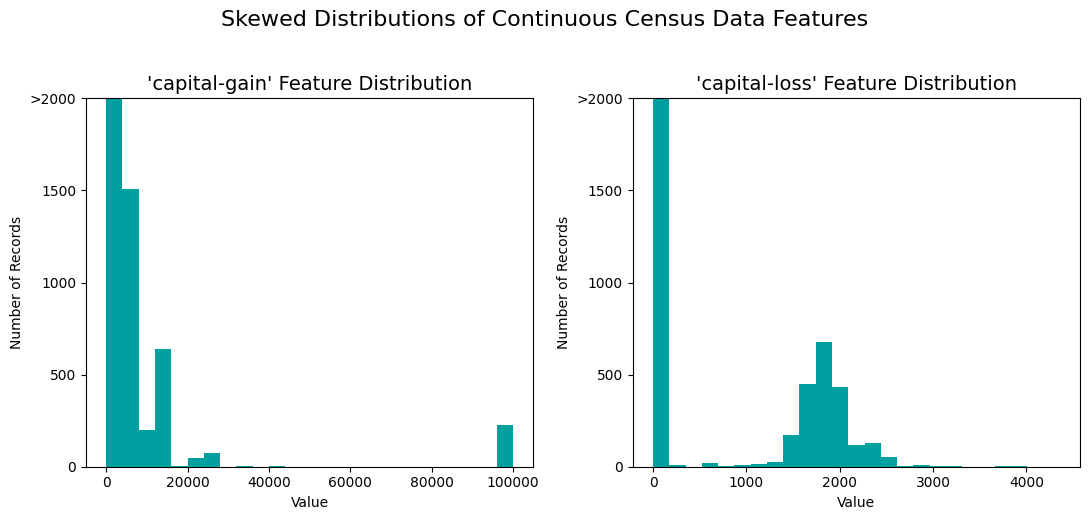

In [7]:
# Split the data into features and target label
income_raw = data['income']
features_raw = data.drop('income', axis = 1)

# Visualize skewed continuous features of original data
vs.distribution(data)

From the above distribution plots, `capital-gain` and `capital-loss` are highly skewed: most values sit near zero with a long tail of large outliers, which can degrade the performance of many learning algorithms if left untransformed.

A log transform compresses this skew. Since $\log(0)$ is undefined, values are shifted by a small constant above 0 before transforming.


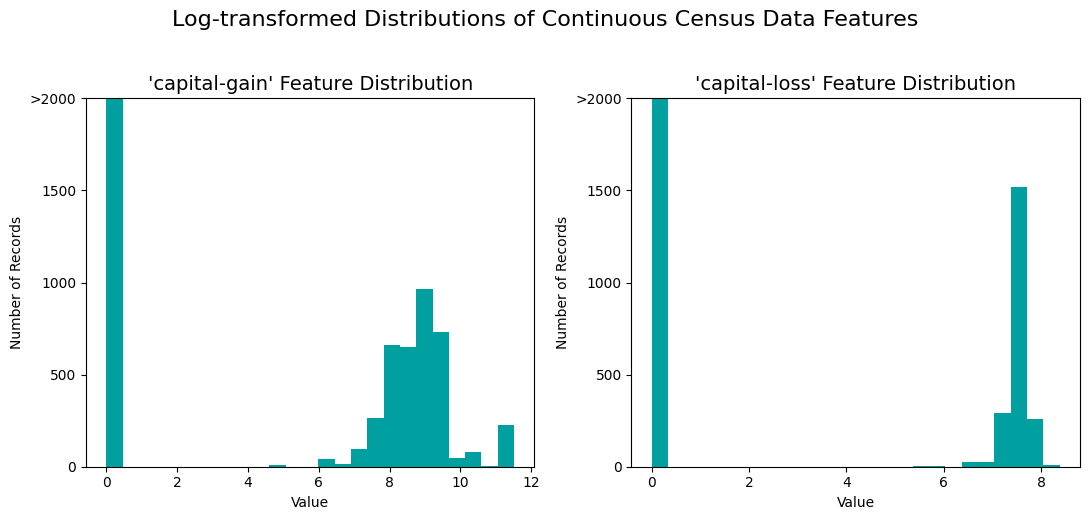

In [8]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features_log_transformed = pd.DataFrame(data = features_raw)
features_log_transformed[skewed] = features_raw[skewed].apply(lambda x: np.log(x + 1))

# Visualize the new log distributions
vs.distribution(features_log_transformed, transformed = True)

### Normalizing Numerical Features

Numerical features are scaled to [0, 1] with `MinMaxScaler` ([sklearn docs](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)) so no feature dominates purely due to its original scale. Scaled values no longer correspond directly to their original units.


In [9]:
# Import sklearn.preprocessing.MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

features_log_minmax_transform = pd.DataFrame(data = features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])

# Show an example of a record with scaling applied
display(features_log_minmax_transform.head(n = 5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Categorical Encoding

Categorical features are one-hot encoded with [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html). The target label `income` is mapped to 0 (`<=50K`) and 1 (`>50K`).


In [10]:
# One-hot encode the 'features_log_minmax_transform' data using pandas.get_dummies()
features_final = pd.get_dummies(features_log_minmax_transform).astype(int)

# Encode the 'income_raw' data to numerical values
income = income_raw.apply(lambda x: 1 if x == '>50K' else 0)

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print("{} total features after one-hot encoding.".format(len(encoded)))

# See the encoded feature names
print(encoded)


103 total features after one-hot encoding.
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'education_level_ 10th', 'education_level_ 11th', 'education_level_ 12th', 'education_level_ 1st-4th', 'education_level_ 5th-6th', 'education_level_ 7th-8th', 'education_level_ 9th', 'education_level_ Assoc-acdm', 'education_level_ Assoc-voc', 'education_level_ Bachelors', 'education_level_ Doctorate', 'education_level_ HS-grad', 'education_level_ Masters', 'education_level_ Preschool', 'education_level_ Prof-school', 'education_level_ Some-college', 'marital-status_ Divorced', 'marital-status_ Married-AF-spouse', 'marital-status_ Married-civ-spouse', 'marital-status_ Married-spouse-absent', 'marital-status_ Never-married', 'marital-status_ Separated', 'marital-status_ Widowed', 'occupation_ A

### Train/Test Split

Data is split 80/20 into training and test sets.


In [11]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_final, 
                                                    income, 
                                                    test_size = 0.2, 
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 36177 samples.
Testing set has 9045 samples.


## Model Selection and Evaluation

Three supervised classifiers -- selected and justified below -- are trained and compared against a naive baseline.


### Evaluation Metric: F-beta Score

phiAI cares more about precision than recall (see Problem Definition): flagging a low-income individual as a likely donor wastes outreach effort, while missing some high earners is a more tolerable cost. Plain accuracy is also unsuitable, since most individuals in this dataset earn `<=50K` -- a naive "always predict `<=50K`" classifier would score high on accuracy while being useless for donor identification.

F-beta score with $\beta = 0.5$ is used instead, which weights precision above recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{precision \cdot recall}{\left( \beta^2 \cdot precision \right) + recall} $$


### Naive Predictor Benchmark

A baseline model that always predicts "income > $50,000" establishes a floor that the trained models must beat. In this setting, precision equals accuracy (no true/false negatives are produced) and recall is 1.


In [12]:
TP = np.sum(income) # Counting the ones as this is the naive case. Note that 'income' is the 'income_raw' data encoded to numerical values done in the data preprocessing step.
FP = income.count() - TP # Specific to the naive case

TN = 0 # No predicted negatives in the naive case
FN = 0 # No predicted negatives in the naive case

# Calculate accuracy, precision and recall
accuracy = (TP + TN) / n_records
recall = TP / (TP + FN)
precision = TP / (TP + FP)

# Calculate F-score using the formula above for beta = 0.5 and correct values for precision and recall.
beta = 0.5
fscore = (1 + beta*beta) * precision * recall / (beta*beta*precision + recall)

# Print the results 
print("Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(accuracy, fscore))

Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


### Candidate Models

Considered from scikit-learn's [supervised learning catalog](http://scikit-learn.org/stable/supervised_learning.html): Gaussian Naive Bayes, Decision Trees, ensemble methods (Bagging, AdaBoost, Random Forest, Gradient Boosting), K-Nearest Neighbors, SGD Classifier, SVM, and Logistic Regression.

Three candidate models are evaluated. What makes these models are good candidates for the problem?

- **Decision Trees**: The dataset features a mix of continuous (e.g., age, capital-gain) and categorical variables (e.g., workclass, education), which decision trees handle natively without assuming linearity. As a binary classification task for income prediction, similar applications show effectiveness in handling such demographic and mixed-feature data for outcomes like credit risk.

- **Support Vector Machines (SVM)**: This is a binary classification task on census data with mixed features, where SVMs have been directly applied to the Income Evaluation dataset for predicting >$50K income after encoding categoricals. SVMs suit the potentially non-linear relationships in demographic features like education and occupation.

- **Logistic Regression**: The binary income classification on census data aligns with logistic regression's strengths, as demonstrated in direct applications to similar datasets for predicting >$50K income. After one-hot encoding categoricals, it can model probabilities efficiently on this demographic data.

### Training and Prediction Pipeline

A reusable pipeline trains each candidate model on a given sample size and records training time, prediction time, accuracy, and F-beta score on both a training subset and the full test set.


In [13]:
# Import two metrics from sklearn - fbeta_score and accuracy_score
from sklearn.metrics import fbeta_score, accuracy_score

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test): 
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - sample_size: the size of samples (number) to be drawn from training set
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''
    
    results = {}
    
    # Fit the learner to the training data using slicing with 'sample_size' using .fit(training_features[:], training_labels[:])
    start = time() # Get start time
    learner = learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time() # Get end time
    
    # Calculate the training time
    results['train_time'] = end - start
        
    # Get the predictions on the test set(X_test),
    #       then get predictions on the first 300 training samples(X_train) using .predict()
    start = time() # Get start time
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time() # Get end time
    
    # Calculate the total prediction time
    results['pred_time'] = end - start
            
    # Compute accuracy on the first 300 training samples which is y_train[:300]
    results['acc_train'] = accuracy_score(y_train[:300], predictions_train)
        
    # Compute accuracy on test set using accuracy_score()
    results['acc_test'] = accuracy_score(y_test, predictions_test)
    
    # Compute F-score on the the first 300 training samples using fbeta_score()
    results['f_train'] = fbeta_score(y_train[:300], predictions_train, beta=0.5)
        
    # Compute F-score on the test set which is y_test
    results['f_test'] = fbeta_score(y_test, predictions_test, beta=0.5)
       
    # Success
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))
        
    # Return the results
    return results

### Initial Model Comparison

Each candidate model is trained at 1%, 10%, and 100% of the training data to compare performance and computational cost as data volume scales.


DecisionTreeClassifier trained on 361 samples.
DecisionTreeClassifier trained on 3617 samples.
DecisionTreeClassifier trained on 36177 samples.
SVC trained on 361 samples.
SVC trained on 3617 samples.
SVC trained on 36177 samples.
LogisticRegression trained on 361 samples.
LogisticRegression trained on 3617 samples.
LogisticRegression trained on 36177 samples.


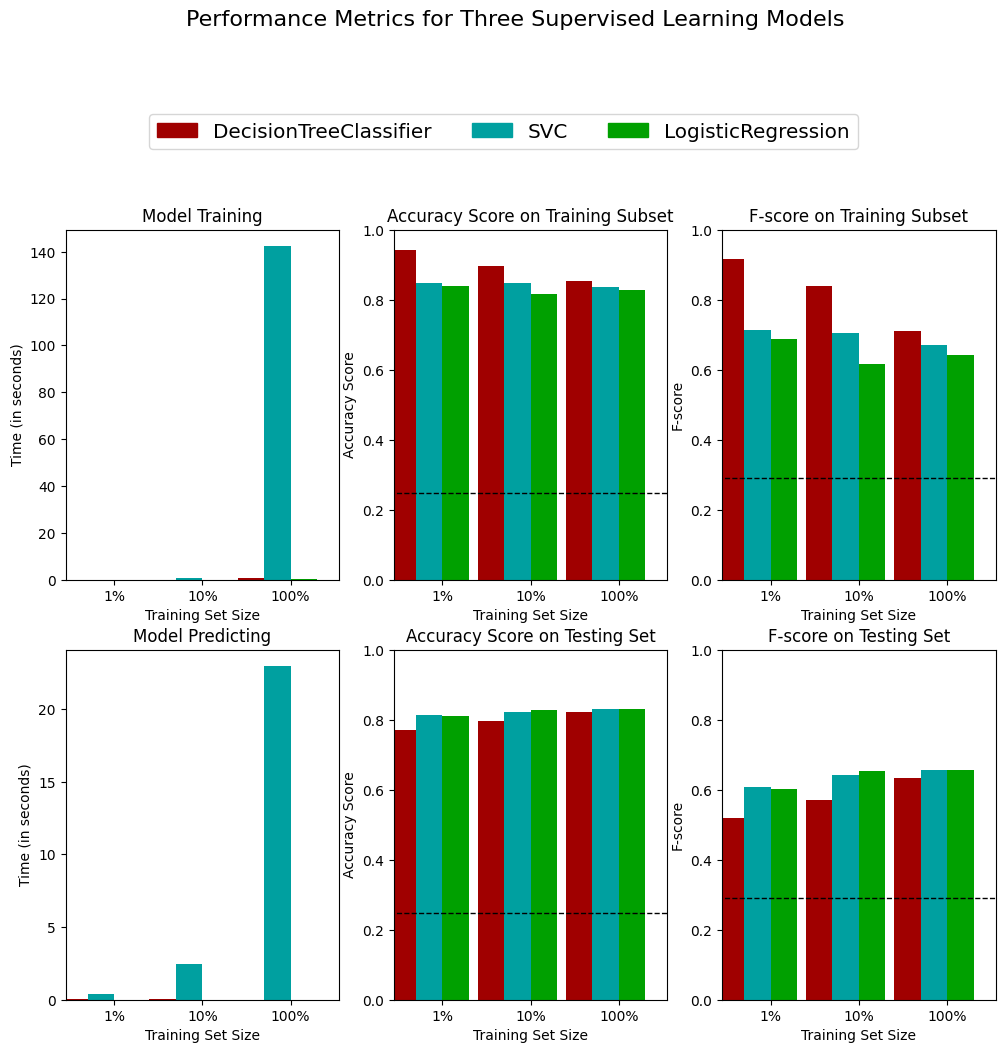

In [ ]:
# Import the three supervised learning models from sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Initialize the three models
clf_A = DecisionTreeClassifier(random_state=0)
clf_B = SVC()
clf_C = LogisticRegression()

# Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
samples_100 = len(y_train)
samples_10 = int(len(y_train) * 0.1)
samples_1 = int(len(y_train) * 0.01)

# Collect results on the learners
results = {}
for clf in [clf_A, clf_B, clf_C]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = \
        train_predict(clf, samples, X_train, y_train, X_test, y_test)

# Run metrics visualization for the three supervised learning models chosen
vs.evaluate(results, accuracy, fscore)

In [15]:
# Summarize numeric results for each model across sample sizes
summary_rows = []
for name, sizes in results.items():
    for label, i in zip(['1%', '10%', '100%'], [0, 1, 2]):
        r = sizes[i]
        summary_rows.append({
            'Model': name,
            'Training Size': label,
            'Train Time (s)': round(r['train_time'], 4),
            'Predict Time (s)': round(r['pred_time'], 4),
            'Test Accuracy': round(r['acc_test'], 4),
            'Test F-score': round(r['f_test'], 4),
        })

results_df = pd.DataFrame(summary_rows)
display(results_df)


,Model,Training Size,Train Time (s),Predict Time (s),Test Accuracy,Test F-score
0,DecisionTreeClassifier,1%,0.0054,0.0185,0.7696,0.5186
1,DecisionTreeClassifier,10%,0.0411,0.0155,0.7952,0.5719
2,DecisionTreeClassifier,100%,0.6175,0.0127,0.8210,0.6342
3,SVC,1%,0.0081,0.4195,0.8124,0.6090
4,SVC,10%,0.6585,2.4532,0.8234,0.6423
5,SVC,100%,142.2786,22.9441,0.8303,0.6573
6,LogisticRegression,1%,0.0207,0.0091,0.8093,0.6033
7,LogisticRegression,10%,0.0402,0.0099,0.8281,0.6529
8,LogisticRegression,100%,0.5197,0.0130,0.8303,0.6572


### Evaluating the Comparison and Choosing a Model

**`DecisionTreeClassifier` underperforms the other two on test data at every sample size.** Even at 100% training data, its test F-score (0.6342) trails both `SVC` (0.6573) and `LogisticRegression` (0.6572) noticeably, and its test accuracy (0.8210) is the lowest of the three -- consistent with the model overfitting to patterns specific to its training data rather than generalizing as well.

**`SVC` and `LogisticRegression` are, for practical purposes, tied on test performance.** At 100% training data: SVC scores 0.8303 accuracy / 0.6573 F-score, and LogisticRegression scores 0.8303 accuracy / 0.6572 F-score -- identical to four decimal places on accuracy, and a difference of 0.0001 on F-beta, well within noise. Both comfortably beat the naive baseline (0.2478 accuracy, 0.2917 F-score).

**Compute cost is not a minor tiebreaker here -- it's decisive.** At 100% training data, `SVC` takes 142.28s to train and 22.94s to predict, versus `LogisticRegression`'s 0.52s and 0.01s: roughly 270x and 1,760x slower respectively, for a performance difference of one hundredth of an F-score point. For a nonprofit like phiAI re-running this model periodically against a growing contact list, that cost is very hard to justify against an essentially identical result.

**The dataset's features don't give `SVC` anything to offset that cost, either.** After one-hot encoding, the feature space has 103 columns, of which only 5 (`age`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`) are continuous -- the remaining ~98 are sparse binary indicators from categorical fields like `workclass`, `education_level`, `occupation`, and `native-country`. High-dimensional, mostly-binary feature spaces like this tend to already be close to linearly separable, which is why linear models routinely match kernel methods in similar settings (e.g. bag-of-words text classification). `SVC`'s default RBF kernel exists to model non-linear decision boundaries, but that capacity only pays off when the data has non-linear structure left to exploit -- and the tied accuracy here is itself the evidence that it doesn't: if the RBF kernel were adding value, SVC's score would lead, not tie. The training-time blowup is also consistent with this: RBF-kernel SVMs scale roughly O(n^2) to O(n^3) with sample size, which is exactly the kind of cost this dataset's ~36,000 training rows triggers for no corresponding accuracy gain.

**Final model selection:** `LogisticRegression` is carried forward into hyperparameter tuning. With `SVC` and `LogisticRegression` statistically tied on accuracy and F-score, and with `SVC` both far more expensive to train/predict and structurally unsuited to this feature space's near-linear separability, `LogisticRegression` is the clear practical choice.


### Model Explanation (Non-Technical)

A plain-language description of how the selected model works, suitable for a non-technical stakeholder audience.

Logistic Regression works like a scorecard. For each piece of information about a person -- their occupation, education level, hours worked, marital status, and so on -- the model learns a weight: how much that factor typically pushes someone's likelihood of earning over $50,000 up or down. To make a prediction, it adds up all of these weighted factors for a given person into a single score, then converts that score into a probability between 0% and 100% using a smooth S-shaped curve.

If the resulting probability is above 50%, the model predicts "income > $50,000"; otherwise it predicts "income <= $50,000". Because the model outputs an actual probability rather than just a yes/no label, phiAI can also see *how confident* the model is about a given individual -- useful for prioritizing outreach toward the highest-probability likely donors first, rather than treating every predicted "yes" identically. Key strengths: fast to train and use even on large datasets, straightforward to explain (each factor's weight shows directly how much it matters), and it produces well-calibrated probabilities rather than a hard cutoff alone.

## Model Tuning

The best-performing candidate, `LogisticRegression`, is selected and optimized via grid search over the full training set.


### Grid Search Tuning

`GridSearchCV` is used to tune the selected model's hyperparameters, optimizing for F-beta score ($\beta = 0.5$) via [`make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).


In [16]:
# Import 'GridSearchCV', 'make_scorer', and any other necessary libraries
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Initialize the classifier
# solver='liblinear' supports l1_ratio=0 (L2) and l1_ratio=1 (L1); elastic-net (0 < l1_ratio < 1) is not
# supported by liblinear, so the grid below only searches the two extremes
clf = LogisticRegression(max_iter=1000, random_state=0, solver='liblinear')

# Create the parameters list to tune
parameters = {
    "C": [0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0, 1]  # 0 = L2 penalty, 1 = L1 penalty (replaces the deprecated 'penalty' param)
}

# Make an fbeta_score scoring object using make_scorer()
scorer = make_scorer(fbeta_score, beta=0.5)

# Perform grid search on the classifier using 'scorer' as the scoring method using GridSearchCV()
grid_obj = GridSearchCV(clf, parameters, scoring=scorer)

# Fit the grid search object to the training data and find the optimal parameters using fit()
grid_fit = grid_obj.fit(X_train, y_train)

# Get the estimator
best_clf = grid_fit.best_estimator_

# Make predictions using the unoptimized and optimized model
predictions = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions = best_clf.predict(X_test)

# Report the before-and-after scores
print("Unoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta = 0.5)))
print("\nOptimized Model\n------")
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("Final F-score on the testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))


Unoptimized model
------
Accuracy score on testing data: 0.8304
F-score on testing data: 0.6577

Optimized Model
------
Final accuracy score on the testing data: 0.8306
Final F-score on the testing data: 0.6581


In [17]:
print(grid_fit.best_params_)

{'C': 1, 'l1_ratio': 1}


### Tuned Model Results

Accuracy and F-score for the tuned model, compared against the untuned model and the naive baseline.


#### Results:

|     Metric     | Unoptimized Model | Optimized Model |
| :------------: | :---------------: | :-------------: | 
| Accuracy Score |     0.8304        |   0.8306         |
| F-score        |     0.6577        |   0.6581         |


Grid search selected `C=1` with `l1_ratio=1` (equivalent to a pure L1 penalty), improving accuracy from 0.8304 to 0.8306 and F-score from 0.6577 to 0.6581 -- a very small gain in both. This is consistent with the model comparison earlier: the untuned Logistic Regression was already close to its ceiling on this dataset, so tuning only refines it marginally rather than transforming its performance.

Against the naive predictor (0.2478 accuracy, 0.2917 F-score), both the unoptimized and optimized models represent a large, meaningful improvement. The practical takeaway for phiAI is that the untuned model would have been nearly as good on its own -- tuning here is worth doing since it's inexpensive for Logistic Regression, but it isn't where the model's real value comes from.

## Feature Importance

Identifying which features carry the most predictive power simplifies the model and clarifies what drives its predictions. A classifier with a `feature_importances_` attribute is fit to the training data to rank the top five features.


### Extracting Feature Importance

A model is trained on the full training set and its `feature_importances_` attribute is used to rank features.


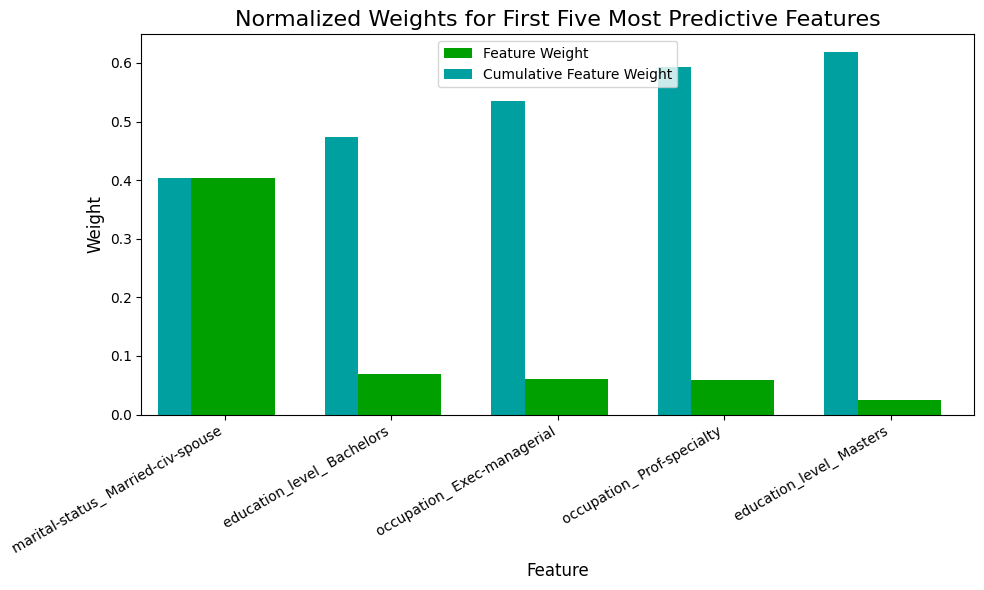

In [18]:
# Import a supervised learning model that has 'feature_importances_'
from sklearn.tree import DecisionTreeClassifier

# Train the supervised model on the training set using .fit(X_train, y_train)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Extract the feature importances using .feature_importances_ 
importances = model.feature_importances_

# Plot
vs.feature_plot(importances, X_train, y_train)

In [19]:
indices = np.argsort(importances)[::-1]
columns = X_train.columns.values[indices[:5]]

columns

array(['marital-status_ Married-civ-spouse', 'education_level_ Bachelors',
       'occupation_ Exec-managerial', 'occupation_ Prof-specialty',
       'education_level_ Masters'], dtype=object)

### Feature Selection

The top five features account for more than half of total feature importance. The tuned model is retrained on this reduced feature set to assess the performance/complexity trade-off.


In [20]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_clf)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))
print("\nFinal Model trained on reduced data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, reduced_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, reduced_predictions, beta = 0.5)))

Final Model trained on full data
------
Accuracy on testing data: 0.8306
F-score on testing data: 0.6581

Final Model trained on reduced data
------
Accuracy on testing data: 0.8192
F-score on testing data: 0.6302


### Effect of Feature Selection

Comparison of F-score and accuracy on the reduced (top-5) feature set versus the full feature set, and whether the reduced set would be preferable under training-time constraints.


**Accuracy** decreased from **0.8306** (full, 103-feature model) to **0.8192** (reduced, 5-feature model), a drop of about **1.14 percentage points**. **F-score** decreased from **0.6581** to **0.6302**, a larger relative drop of about **4.2%**, indicating the reduced model is noticeably weaker at correctly identifying the positive (high-income) class specifically, even though overall accuracy holds up reasonably well.

Unlike the earlier SVC-based comparison, where feature reduction would have meaningfully cut training time, Logistic Regression is already fast on the full 103-feature set (well under a second). So the training-time savings from reducing to 5 features are negligible in absolute terms, and don't come close to offsetting a 4% drop in F-score. For phiAI, the full-feature model is the better choice: the reduced model would only be worth using if there were a separate reason to prefer fewer features (e.g. data collection cost, or wanting a simpler model to explain), not for speed.

## Notebook Summary

This notebook addressed a binary classification problem: predicting whether an individual's annual income exceeds \$50,000, using the UCI Adult/Census Income dataset, to help the nonprofit phiAI prioritize donor outreach for its STEM scholarship programs. After log-transforming skewed continuous features, scaling numerical features, and one-hot encoding categorical variables, three supervised models -- Decision Tree, SVC, and Logistic Regression -- were trained and compared using F-beta (beta=0.5) score, which weights precision over recall to reflect phiAI's preference for avoiding wasted outreach on false positives. `LogisticRegression` was selected as the final model: it tied `SVC` on test accuracy and F-score while training roughly 270x faster, and the dataset's mostly sparse, one-hot-encoded feature space gave `SVC`'s non-linear kernel no advantage to offset that cost. Tuned via `GridSearchCV`, the final model achieved 0.8306 accuracy and 0.6581 F-score on the test set, a substantial improvement over the naive baseline (0.2478 accuracy, 0.2917 F-score). Feature-importance analysis showed marital status, occupation, and education level were the strongest predictors, and a reduced five-feature model retained most of the predictive power (0.8192 accuracy, 0.6302 F-score) with only a modest drop from the full model. Key limitations include the dataset's age (1994 data) and the presence of demographic features that carry historical bias risk, both discussed further below.

## Limitations, Potential Bias, and Mitigation

**Limitation:** The dataset is drawn from 1994 U.S. Census data, so the economic patterns it reflects (income levels, occupational distributions, cost of living) are three decades out of date. A model trained on it would not generalize reliably to present-day income prediction without retraining on more recent data.

**Potential bias:** `sex`, `race`, and `marital-status` are included as raw features. Because historical income data reflects real, documented inequities in pay and occupational access along these lines, a model trained directly on them risks learning and reproducing those disparities rather than identifying donor potential in a fair way -- for example, systematically under-flagging qualified individuals from groups that were historically paid less for comparable work.

**Mitigation step taken/proposed:** The feature-importance analysis above shows that `sex` and `race` are not among the top five most predictive features -- marital status, occupation, and education level dominate -- which suggests the model is not leaning heavily on demographic identity to make its prediction. As a further mitigation, phiAI could explicitly exclude `sex` and `race` from the feature set and re-run the reduced-feature comparison above to confirm performance does not depend on them, and should periodically audit outreach outcomes across demographic groups to check the model isn't systematically under-selecting any group.